In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def show_img(titulo, image):
    cv2.imshow(titulo, image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [3]:
# processo padrão de ler a imagem e criar um canva vazio
img = cv2.imread('assets/fotos/cats.jpg')
blank = np.zeros(img.shape[:2], dtype='uint8')

In [4]:
# primeiro, será calculado o histograma da imagem em cinza

cinza = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show_img('Gatinhos', cinza)

In [5]:
# Histograma de P&B
cinza_hist = cv2.calcHist([cinza], [0], None,[256],[0,256])

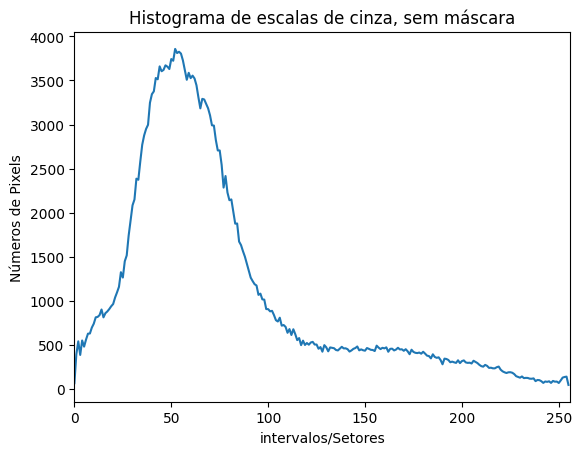

In [6]:
# Plotando a imagem do histograma de escalas de cinza
plt.figure()
plt.title('Histograma de escalas de cinza, sem máscara')
plt.xlabel('intervalos/Setores')
plt.ylabel('Números de Pixels')
plt.plot(cinza_hist)
plt.xlim([0, 256])
plt.show()

In [7]:
# Revertendo a imagem para ter uma melhor compreensão
show_img('Gatinhos', cinza)

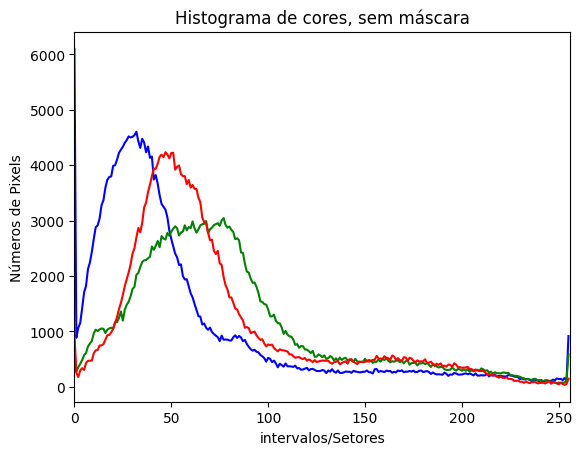

In [8]:
plt.figure()
plt.title('Histograma de cores, sem máscara')
plt.xlabel('intervalos/Setores')
plt.ylabel('Números de Pixels')
colors =['b', 'g', 'r']
for channel, cor in enumerate(colors):
    hist = cv2.calcHist([img],[channel], None,[256],[0,256])
    plt.plot(hist, color=cor)
    plt.xlim([0,256])

plt.show()

In [9]:
# analisando trechos específico da imagem, aplicando apenas uma máscara na imagem e traçando o histograma
mask = cv2.circle(blank, (img.shape[1//2],img.shape[0]//2),100, 255,-1)

masked = cv2.bitwise_and(img, img, mask=mask)
show_img('Mascara na imagem', masked)

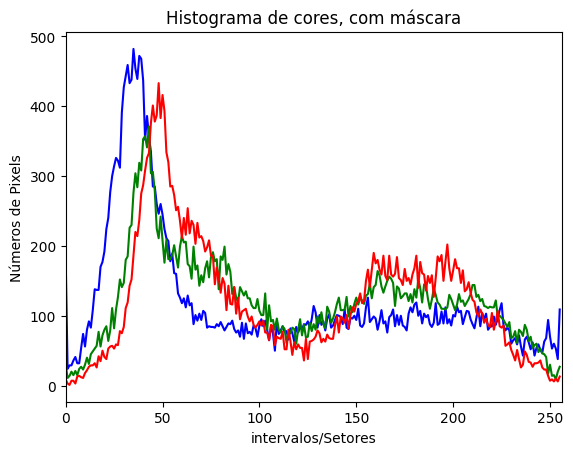

In [10]:
plt.figure()
plt.title('Histograma de cores, com máscara')
plt.xlabel('intervalos/Setores')
plt.ylabel('Números de Pixels')
colors =['b', 'g', 'r']
for channel, cor in enumerate(colors):
    hist = cv2.calcHist([img],[channel], mask,[256],[0,256])
    plt.plot(hist, color=cor)
    plt.xlim([0,256])

plt.show()